In [3]:
# ── Install & Import Libraries ──────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import re
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download("wordnet")
nltk.download("omw-1.4")

STOP_WORDS = set(stopwords.words('english'))
_LEMMA = WordNetLemmatizer()

_URL_RE = re.compile(r"(https?://\S+|www\.\S+)")
_NON_ALPHA_RE = re.compile(r"[^a-z\s]")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:

# ── Load Dataset ─────────────────────────────────────

df = pd.read_csv('/content/data_to_be_cleansed.csv')


print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nClass counts:")
print(df.iloc[:, -1].value_counts())
print("\nFirst 3 rows:")
df.head(3)


Shape: (5957, 4)

Column names: ['Unnamed: 0', 'text', 'title', 'target']

Class counts:
target
1    1202
3    1201
4    1188
2    1185
0    1181
Name: count, dtype: int64

First 3 rows:


,Unnamed: 0,text,title,target
0,0,Welcome to /r/depression's check-in post - a p...,"Regular check-in post, with information about ...",1
1,1,We understand that most people who reply immed...,Our most-broken and least-understood rules is ...,1
2,2,Anyone else just miss physical touch? I crave ...,"I haven’t been touched, or even hugged, in so ...",1


In [7]:

# A sample post from each target class
for t in sorted(df['target'].unique()):
    print(f"\n{'='*60}")
    print(f"TARGET = {t}")
    print(f"Title : {df[df['target']==t]['title'].iloc[0]}")
    print(f"Text  : {df[df['target']==t]['text'].iloc[0][:200]}")


TARGET = 0
Title : Free Covid-19 Anxiety e-Workbook. Please, take care of yourselves and of each other. See text for link.
Text  : The book is available [Here](https://thewellnesssociety.org/free-coronavirus-anxiety-workbook/) from The Wellness Society. Everyone right now needs a little extra help and hopefully, this e-book can a

TARGET = 1
Title : Regular check-in post, with information about our rules and wikis
Text  : Welcome to /r/depression's check-in post - a place to take a moment and share what is going on and how you are doing. If you have an accomplishment you want to talk about (these shouldn't be standalon

TARGET = 2
Title : Announcement on our AMA with Dr. Tracey Marks
Text  : Hey all, we’ve rescheduled our AMA with Dr Tracy Marks while we work out the technical logistics.

&amp;#x200B;

This decision was not made lightly, but we do need more time to make sure that everythi

TARGET = 3
Title : Is there anyone interested in joining a group for AvPD on Telegram?
Text  : *

In [8]:
# data cleaning
# Map numeric targets to class names
label_map = {
    0: 'anxiety',
    4: 'anxiety',
    1: 'depression',
    2: 'neutral',
    3: 'neutral'
}
# Drop the unnecessary index column
df = df.drop(columns=['Unnamed: 0'])

df['label'] = df['target'].map(label_map)

# Combine title + text into one field
df['full_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# Drop rows with missing values
df = df.dropna(subset=['full_text', 'label'])

print("=== New Class Distribution ===")
print(df['label'].value_counts())

print("\n=== Sample rows ===")
df[['full_text', 'label']].head(5)

=== New Class Distribution ===
label
neutral       2386
anxiety       2369
depression    1202
Name: count, dtype: int64

=== Sample rows ===


,full_text,label
0,"Regular check-in post, with information about ...",depression
1,Our most-broken and least-understood rules is ...,depression
2,"I haven’t been touched, or even hugged, in so ...",depression
3,Being Depressed is Embarrassing I’m just so as...,depression
4,I'm desperate for a friend and to feel loved b...,depression


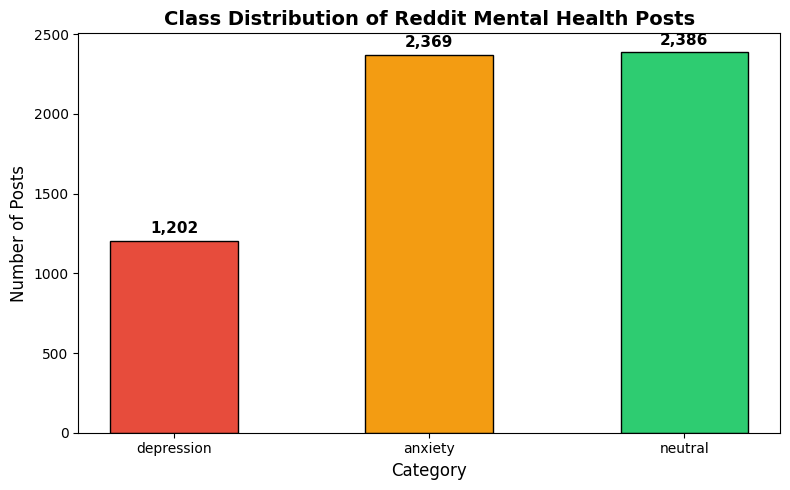

Saved: class_distribution.png


In [9]:
# EDA
# ── 1. Class Distribution Bar Chart ─────────────────────────
plt.figure(figsize=(8, 5))
order = ['depression', 'anxiety', 'neutral']
counts = df['label'].value_counts().reindex(order)
colors = ['#e74c3c', '#f39c12', '#2ecc71']

bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Class Distribution of Reddit Mental Health Posts', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Saved: class_distribution.png")


=== Post Length Stats by Class ===
             count    mean     std  min   25%    50%    75%     max
label                                                              
anxiety     2369.0  148.82  156.12  1.0  51.0  104.0  191.0  1606.0
depression  1202.0  172.62  159.78  6.0  61.0  128.5  227.0  1663.0
neutral     2386.0  155.84  181.88  1.0  57.0  114.0  205.0  5419.0


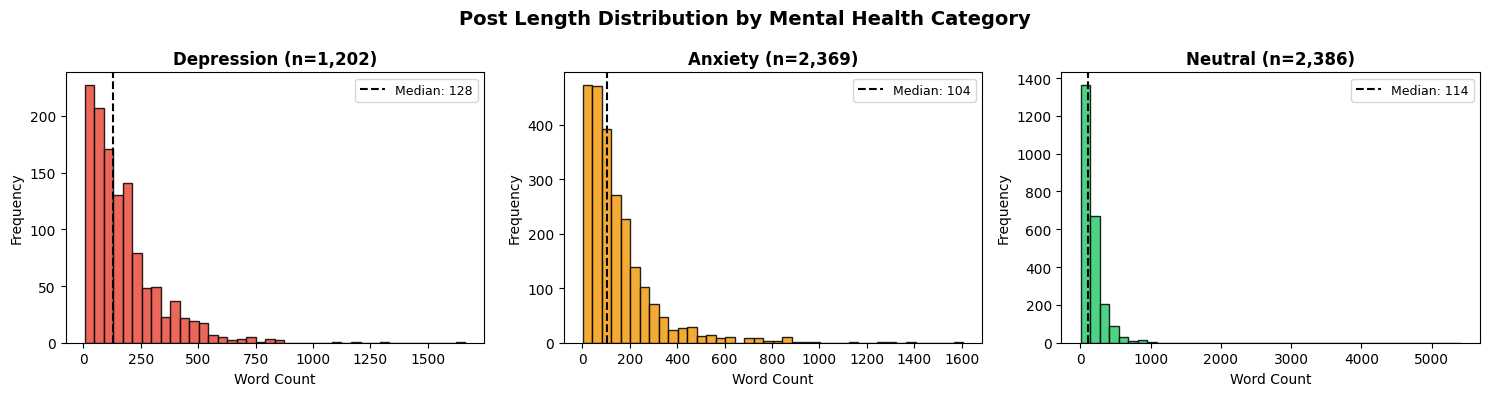

Saved: post_length_histogram.png


In [10]:

# ── 2. Post Length Analysis ──────────────────────────────────
df['post_length'] = df['full_text'].apply(lambda x: len(str(x).split()))

print("\n=== Post Length Stats by Class ===")
print(df.groupby('label')['post_length'].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_map = {'depression': '#e74c3c', 'anxiety': '#f39c12', 'neutral': '#2ecc71'}

for ax, label in zip(axes, ['depression', 'anxiety', 'neutral']):
    subset = df[df['label'] == label]['post_length']
    ax.hist(subset, bins=40, color=colors_map[label], edgecolor='black', alpha=0.85)
    ax.set_title(f'{label.capitalize()} (n={len(subset):,})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Word Count', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.axvline(subset.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {subset.median():.0f}')
    ax.legend(fontsize=9)

plt.suptitle('Post Length Distribution by Mental Health Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('post_length_histogram.png', dpi=150)
plt.show()
print("Saved: post_length_histogram.png")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


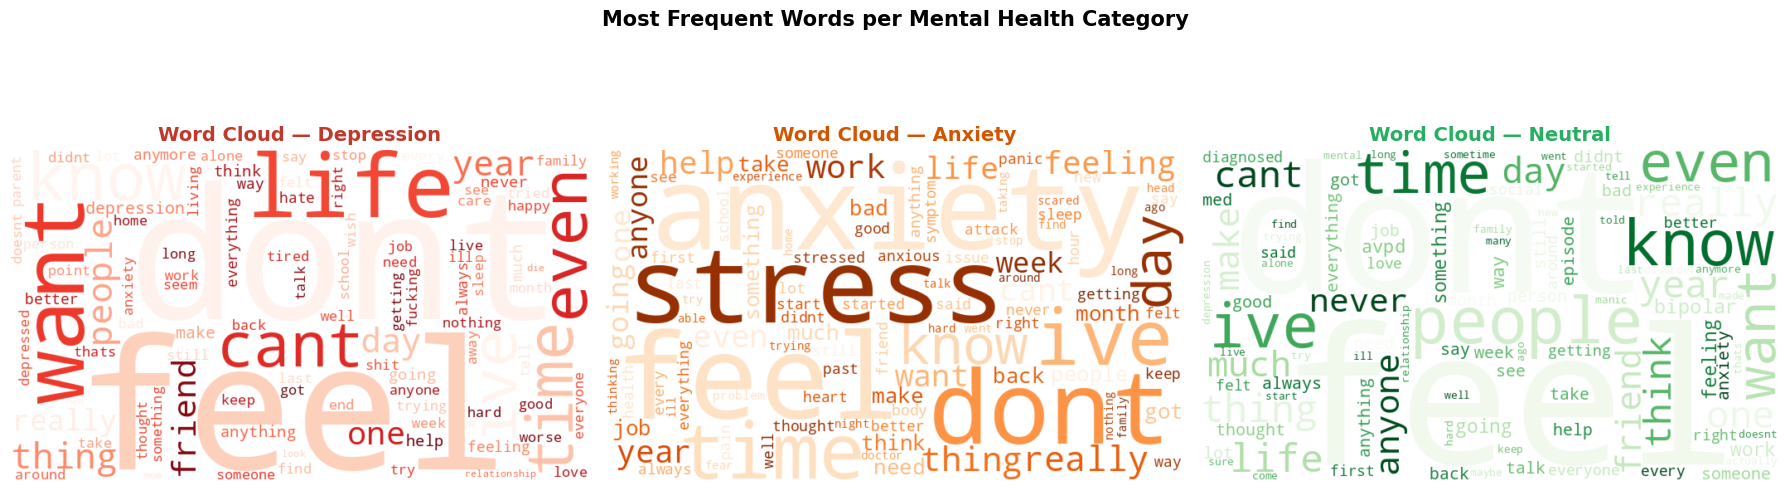

Saved: wordclouds.png


In [11]:
# Word clouds
nltk.download('stopwords')
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))

# ── Clean text for word cloud ────────────────────────────────
def clean_for_wc(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)          # remove punctuation/numbers
    words = text.split()
    words = [w for w in words if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(words)

df['clean_text'] = df['full_text'].apply(clean_for_wc)

# ── Generate Word Clouds ─────────────────────────────────────
categories = {
    'depression': ('Reds',   '#c0392b'),
    'anxiety':    ('Oranges','#d35400'),
    'neutral':    ('Greens', '#27ae60')
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, (cmap, color)) in zip(axes, categories.items()):
    corpus = ' '.join(df[df['label'] == label]['clean_text'])
    wc = WordCloud(
        width=700, height=400,
        background_color='white',
        colormap=cmap,
        max_words=100,
        collocations=False
    ).generate(corpus)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {label.capitalize()}',
                 fontsize=14, fontweight='bold', color=color)

plt.suptitle('Most Frequent Words per Mental Health Category',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()
print("Saved: wordclouds.png")

In [12]:
# Adding common words to list
from collections import Counter
# Get top 50 words per class
top_n = 50
word_sets = {}
for label in ['depression', 'anxiety', 'neutral']:
    corpus = ' '.join(df[df['label'] == label]['clean_text'])
    top_words = set([w for w, _ in Counter(corpus.split()).most_common(top_n)])
    word_sets[label] = top_words

# Find words that appear in ALL three classes
common_all = word_sets['depression'] & word_sets['anxiety'] & word_sets['neutral']
print("=== Words in ALL 3 classes (top 50) ===")
print(sorted(common_all))

=== Words in ALL 3 classes (top 50) ===
['always', 'anyone', 'anything', 'back', 'cant', 'day', 'dont', 'even', 'feel', 'feeling', 'get', 'going', 'good', 'got', 'help', 'ive', 'know', 'life', 'like', 'make', 'much', 'need', 'never', 'one', 'people', 'really', 'something', 'still', 'things', 'think', 'time', 'want', 'way', 'work', 'would', 'years']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


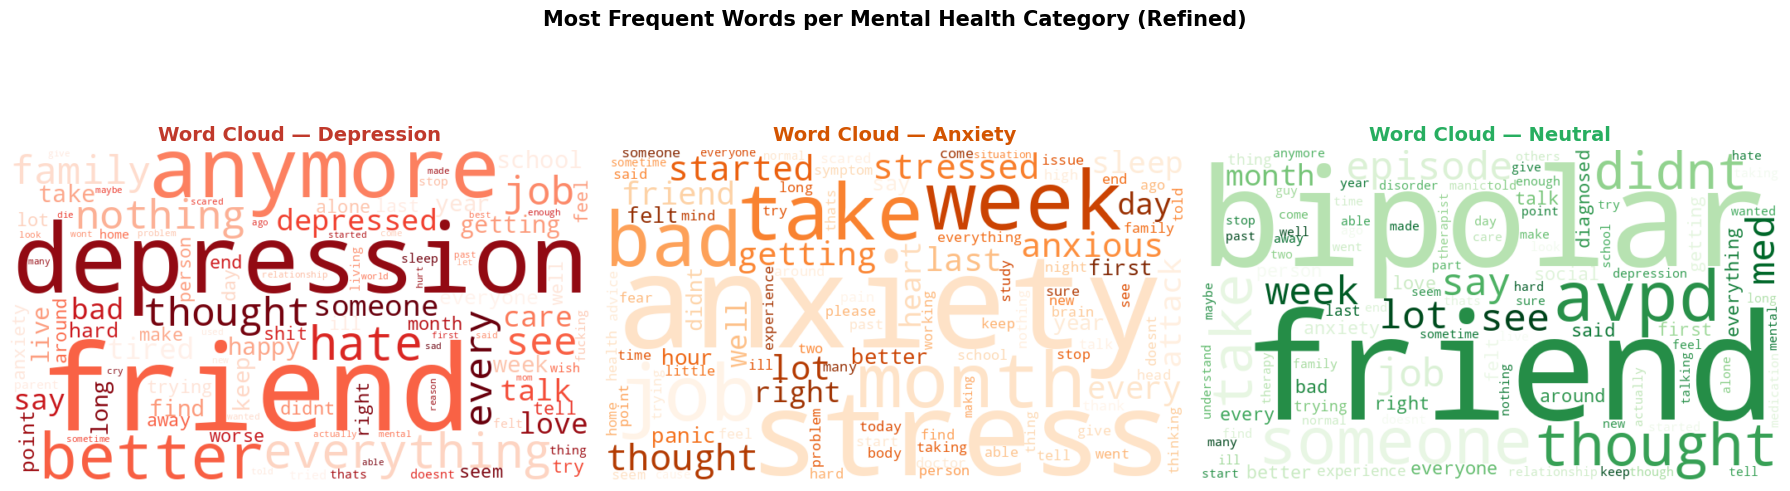

Saved: wordclouds_refined.png


In [13]:
# Removing common words and lemmatization
import re
import nltk
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

STOP_WORDS = set(stopwords.words('english'))
custom_stops = {
    'always', 'anyone', 'anything', 'back', 'cant', 'day', 'dont', 'even',
    'feel', 'feeling', 'get', 'going', 'good', 'got', 'help', 'ive', 'know',
    'life', 'like', 'make', 'much', 'need', 'never', 'one', 'people', 'really',
    'something', 'still', 'things', 'think', 'time', 'want', 'way', 'work',
    'would', 'years'
}
STOP_WORDS_EXTENDED = STOP_WORDS | custom_stops
lemmatizer = WordNetLemmatizer()

# Clean + lemmatize
def clean_for_wc_v3(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)    # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)           # remove punctuation/numbers
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in STOP_WORDS_EXTENDED and len(w) > 2]
    return ' '.join(words)

df['clean_text_v3'] = df['full_text'].apply(clean_for_wc_v3)

# Generate word clouds
categories = {
    'depression': ('Reds',    '#c0392b'),
    'anxiety':    ('Oranges', '#d35400'),
    'neutral':    ('Greens',  '#27ae60')
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, (cmap, color)) in zip(axes, categories.items()):
    corpus = ' '.join(df[df['label'] == label]['clean_text_v3'])
    wc = WordCloud(
        width=700, height=400,
        background_color='white',
        colormap=cmap,
        max_words=100,
        collocations=False
    ).generate(corpus)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {label.capitalize()}',
                 fontsize=14, fontweight='bold', color=color)

plt.suptitle('Most Frequent Words per Mental Health Category (Refined)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds_refined.png', dpi=150)
plt.show()
print("Saved: wordclouds_refined.png")

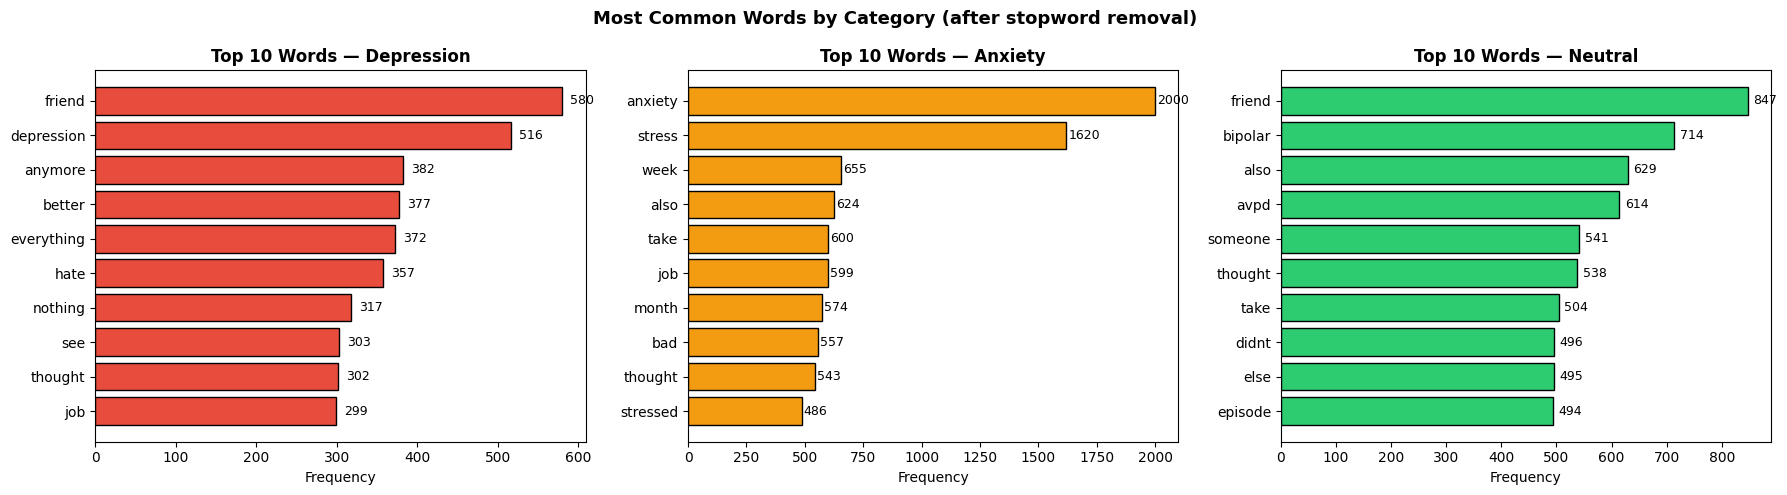

Saved: top_words_per_class.png


In [14]:
# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_list = ['#e74c3c', '#f39c12', '#2ecc71']

for ax, label, color in zip(axes, ['depression', 'anxiety', 'neutral'], colors_list):
    corpus = ' '.join(df[df['label'] == label]['clean_text_v3'])  # using refined text
    word_freq = Counter(corpus.split()).most_common(10)
    words, freqs = zip(*word_freq)

    ax.barh(words[::-1], freqs[::-1], color=color, edgecolor='black')
    ax.set_title(f'Top 10 Words — {label.capitalize()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency', fontsize=10)
    for i, (w, f) in enumerate(zip(words[::-1], freqs[::-1])):
        ax.text(f + 10, i, str(f), va='center', fontsize=9)

plt.suptitle('Most Common Words by Category (after stopword removal)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('top_words_per_class.png', dpi=150)
plt.show()
print("Saved: top_words_per_class.png")

In [15]:
# ── Summary Stats Table ──────────────────────────────────────
summary = df.groupby('label').agg(
    total_posts=('full_text', 'count'),
    avg_word_count=('post_length', 'mean'),
    median_word_count=('post_length', 'median'),
    max_word_count=('post_length', 'max')
).round(2)

print("=== EDA Summary Table ===")
print(summary)
summary.to_csv('eda_summary.csv')
print("\nSaved: eda_summary.csv")

# ── Save Cleaned Dataset ────────────
df[['full_text', 'clean_text_v3', 'label', 'post_length']].to_csv('cleaned_reddit_data.csv', index=False)
print("Saved: cleaned_reddit_data.csv")

=== EDA Summary Table ===
            total_posts  avg_word_count  median_word_count  max_word_count
label                                                                     
anxiety            2369          148.82              104.0            1606
depression         1202          172.62              128.5            1663
neutral            2386          155.84              114.0            5419

Saved: eda_summary.csv
Saved: cleaned_reddit_data.csv


In [16]:
def preprocessed_text(text: str) -> str:
    """Normalize raw post text for classical ML models."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = _URL_RE.sub(" ", text)
    text = _NON_ALPHA_RE.sub(" ", text)
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 2]
    tokens = [_LEMMA.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["preprocessed_text"] = df["full_text"].apply(preprocessed_text)

print("Cleaned text sample:")
display(df[["full_text", "preprocessed_text", "label"]].sample(3, random_state=42))

Cleaned text sample:


,full_text,preprocessed_text,label
1344,Behaviour become more erratic? Is it normal fo...,behaviour become erratic normal behaviour beco...,anxiety
625,I’m confused please someone help me.( sorry fo...,confused please someone help sorry bad sub typ...,depression
1433,Wanna Do a Stress quiz? Hello! \n\nI'm doing a...,wanna stress quiz hello assignment school stre...,anxiety


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

def make_tfidf_vectorizer(
    max_features: int = 5000,
    ngram_range: tuple[int, int] = (1, 2),
    min_df: int = 2,
) -> TfidfVectorizer:
    """Create a TF-IDF vectorizer for ablation experiments."""
    return TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=min_df,
        sublinear_tf=True,
        strip_accents="unicode",
    )

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["preprocessed_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"],
)

# baseline config
vectorizer = make_tfidf_vectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("TF-IDF shapes:", X_train.shape, X_test.shape)

TF-IDF shapes: (4765, 5000) (1192, 5000)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

def train_models(X, y, random_state: int = 42):
    """Train baseline models. Returns a dict of fitted estimators."""
    models = {
        "logreg_l2": LogisticRegression(
            max_iter=2000, solver="liblinear", penalty="l2", random_state=random_state
        ),
        "logreg_l1": LogisticRegression(
            max_iter=2000, solver="liblinear", penalty="l1", random_state=random_state
        ),
        "mnb": MultinomialNB(),
        "linear_svm": LinearSVC(random_state=random_state),
        "rf": RandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1,
        ),
    }
    for name, model in models.items():
        model.fit(X, y)
        print(f"Trained: {name}")
    return models

models = train_models(X_train, y_train)

ml_artifacts = {
    "vectorizer": vectorizer,
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test,
    "models": models,
}

print("Artifacts ready for evaluation (ml_artifacts).")

Trained: logreg_l2
Trained: logreg_l1
Trained: mnb
Trained: linear_svm
Trained: rf
Artifacts ready for evaluation (ml_artifacts).


In [19]:
from dataclasses import dataclass
from typing import Any, Dict, List, Tuple
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

ML_COL = "preprocessed_text"

# Models same as your baseline training
def build_models(random_state: int = 42) -> Dict[str, Any]:
    return {
        "logreg_l2": LogisticRegression(max_iter=2000, solver="liblinear", penalty="l2", random_state=random_state),
        "logreg_l1": LogisticRegression(max_iter=2000, solver="liblinear", penalty="l1", random_state=random_state),
        "mnb": MultinomialNB(),
        "linear_svm": LinearSVC(random_state=random_state),
        "rf": RandomForestClassifier(n_estimators=300, random_state=random_state, n_jobs=-1),
    }

TFIDF_CONFIGS = [
    {"name": "uni_500",   "max_features": 500,   "ngram_range": (1, 1), "min_df": 2},
    {"name": "uni_1k",    "max_features": 1000,  "ngram_range": (1, 1), "min_df": 2},
    {"name": "uni_5k",    "max_features": 5000,  "ngram_range": (1, 1), "min_df": 2},
    {"name": "uni_10k",   "max_features": 10000, "ngram_range": (1, 1), "min_df": 2},

    {"name": "bi_500",    "max_features": 500,   "ngram_range": (2, 2), "min_df": 2},
    {"name": "bi_1k",     "max_features": 1000,  "ngram_range": (2, 2), "min_df": 2},
    {"name": "bi_5k",     "max_features": 5000,  "ngram_range": (2, 2), "min_df": 2},
    {"name": "bi_10k",    "max_features": 10000, "ngram_range": (2, 2), "min_df": 2},

    {"name": "uni_bi_500","max_features": 500,   "ngram_range": (1, 2), "min_df": 2},
    {"name": "uni_bi_1k", "max_features": 1000,  "ngram_range": (1, 2), "min_df": 2},
    {"name": "uni_bi_5k", "max_features": 5000,  "ngram_range": (1, 2), "min_df": 2},
    {"name": "uni_bi_10k","max_features": 10000, "ngram_range": (1, 2), "min_df": 2},
]
def make_vectorizer(cfg: Dict[str, Any]) -> TfidfVectorizer:
    return TfidfVectorizer(
        max_features=cfg["max_features"],
        ngram_range=cfg["ngram_range"],
        min_df=cfg["min_df"],
        sublinear_tf=True,
        strip_accents="unicode",
    )

def run_tfidf_sweep(
    df: pd.DataFrame,
    text_col: str = ML_COL,
    label_col: str = "label",
    test_size: float = 0.2,
    random_state: int = 42
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    X_train_text, X_test_text, y_train, y_test = train_test_split(
        df[text_col],
        df[label_col],
        test_size=test_size,
        random_state=random_state,
        stratify=df[label_col],
    )

    rows: List[Dict[str, Any]] = []
    best_pack: Dict[str, Any] = {}

    for cfg in TFIDF_CONFIGS:
        vec = make_vectorizer(cfg)
        X_train = vec.fit_transform(X_train_text)
        X_test = vec.transform(X_test_text)

        for model_name, model in build_models(random_state).items():
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            rows.append({
                "tfidf_name": cfg["name"],
                "max_features": cfg["max_features"],
                "ngram_range": str(cfg["ngram_range"]),
                "min_df": cfg["min_df"],
                "model": model_name,
                "accuracy": float(accuracy_score(y_test, preds)),
                "f1_macro": float(f1_score(y_test, preds, average="macro")),
            })

    results = pd.DataFrame(rows).sort_values(["f1_macro", "accuracy"], ascending=False)

    # store best combo artifacts for later evaluation/reporting
    top = results.iloc[0].to_dict()
    best_cfg = next(c for c in TFIDF_CONFIGS if c["name"] == top["tfidf_name"])
    best_vec = make_vectorizer(best_cfg)
    X_train_best = best_vec.fit_transform(X_train_text)
    X_test_best = best_vec.transform(X_test_text)

    best_model = build_models(random_state)[top["model"]]
    best_model.fit(X_train_best, y_train)

    best_pack = {
        "best_cfg": best_cfg,
        "best_vectorizer": best_vec,
        "best_model_name": top["model"],
        "best_model": best_model,
        "X_train": X_train_best,
        "X_test": X_test_best,
        "y_train": y_train,
        "y_test": y_test,
        "results": results,
    }
    return results, best_pack

tfidf_sweep_results, best_tfidf_pack = run_tfidf_sweep(df)

print("Top 10 (by F1-macro):")
display(tfidf_sweep_results.head(10))

ml_artifacts["tfidf_sweep_results"] = tfidf_sweep_results
ml_artifacts["best_tfidf_pack"] = best_tfidf_pack

Top 10 (by F1-macro):


,tfidf_name,max_features,ngram_range,min_df,model,accuracy,f1_macro
49,uni_bi_1k,1000,"(1, 2)",2,rf,0.849832,0.837074
44,uni_bi_500,500,"(1, 2)",2,rf,0.848154,0.835488
9,uni_1k,1000,"(1, 1)",2,rf,0.845638,0.831679
4,uni_500,500,"(1, 1)",2,rf,0.847315,0.831020
54,uni_bi_5k,5000,"(1, 2)",2,rf,0.839765,0.821387
53,uni_bi_5k,5000,"(1, 2)",2,linear_svm,0.831376,0.817111
18,uni_10k,10000,"(1, 1)",2,linear_svm,0.831376,0.815106
14,uni_5k,5000,"(1, 1)",2,rf,0.832215,0.812067
58,uni_bi_10k,10000,"(1, 2)",2,linear_svm,0.826342,0.810672
13,uni_5k,5000,"(1, 1)",2,linear_svm,0.827181,0.810279


In [20]:
# Part 1 - Imports and Setup
# All libraries needed for evaluation, plotting, and analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import label_binarize, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve
)

# Pulling everything from Ml's saved artifacts
vectorizer = ml_artifacts["vectorizer"]
X_train    = ml_artifacts["X_train"]
X_test     = ml_artifacts["X_test"]
y_train    = ml_artifacts["y_train"]
y_test     = ml_artifacts["y_test"]
models     = ml_artifacts["models"]

# Class names used consistently across all plots and tables
CLASSES = ['anxiety', 'depression', 'neutral']

# Readable names for each model key
MODEL_LABELS = {
    "logreg_l2":  "LogReg L2",
    "logreg_l1":  "LogReg L1",
    "mnb":        "Naive Bayes",
    "linear_svm": "Linear SVM",
    "rf":         "Random Forest",
}

print("Setup complete. Models and data loaded from ml_artifacts.")
print("Models available:", list(models.keys()))
print("Test set size:", X_test.shape[0])

Setup complete. Models and data loaded from ml_artifacts.
Models available: ['logreg_l2', 'logreg_l1', 'mnb', 'linear_svm', 'rf']
Test set size: 1192


=== Model Comparison on Test Set ===


,Model,Accuracy,Macro F1,Macro Precision,Macro Recall
0,Random Forest,0.8398,0.8214,0.8571,0.8053
1,Linear SVM,0.8314,0.8171,0.8250,0.8113
2,LogReg L2,0.7987,0.7736,0.8063,0.7601
3,LogReg L1,0.7903,0.7713,0.7861,0.7626
4,Naive Bayes,0.7416,0.6673,0.7764,0.6647


Saved: model_comparison.csv


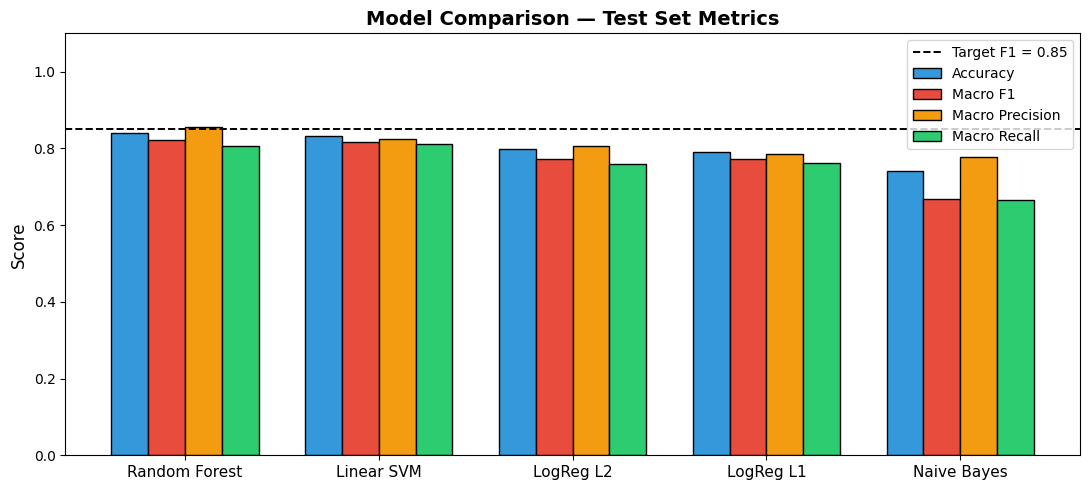

Saved: model_comparison_chart.png


In [21]:
# Part 2 - Test-Set Evaluation
# Run each model on the test set and collect all four metrics

rows = []

for name, model in models.items():
    preds = model.predict(X_test)
    rows.append({
        "Model"           : MODEL_LABELS[name],
        "Accuracy"        : accuracy_score(y_test, preds),
        "Macro F1"        : f1_score(y_test, preds, average="macro"),
        "Macro Precision" : precision_score(y_test, preds, average="macro"),
        "Macro Recall"    : recall_score(y_test, preds, average="macro"),
    })

eval_df = (pd.DataFrame(rows)
             .sort_values("Macro F1", ascending=False)
             .reset_index(drop=True)
             .round(4))

print("=== Model Comparison on Test Set ===")
display(eval_df)

eval_df.to_csv("model_comparison.csv", index=False)
print("Saved: model_comparison.csv")

# Bar chart showing all four metrics side by side for each model
fig, ax = plt.subplots(figsize=(11, 5))

x       = np.arange(len(eval_df))
width   = 0.19
metrics = ["Accuracy", "Macro F1", "Macro Precision", "Macro Recall"]
colors  = ["#3498db", "#e74c3c", "#f39c12", "#2ecc71"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, eval_df[metric], width,
           label=metric, color=color, edgecolor="black")

# dotted line at our target score
ax.axhline(0.85, color="black", linestyle="--", linewidth=1.4, label="Target F1 = 0.85")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(eval_df["Model"], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Comparison — Test Set Metrics", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("model_comparison_chart.png", dpi=150)
plt.show()
print("Saved: model_comparison_chart.png")

In [22]:
# Part 3 - 5-Fold Cross-Validation
# We build pipelines so the vectorizer is re-fitted inside each fold
# This avoids any data leakage from the earlier train/test split

def make_pipeline(model_key, random_state=42):
    vec = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        strip_accents="unicode"
    )
    clf_map = {
        "logreg_l2"  : LogisticRegression(max_iter=2000, solver="liblinear", penalty="l2", random_state=random_state),
        "logreg_l1"  : LogisticRegression(max_iter=2000, solver="liblinear", penalty="l1", random_state=random_state),
        "mnb"        : MultinomialNB(),
        "linear_svm" : LinearSVC(random_state=random_state),
        "rf"         : RandomForestClassifier(n_estimators=300, random_state=random_state, n_jobs=-1),
    }
    return Pipeline([("tfidf", vec), ("clf", clf_map[model_key])])

# Use the full dataset for cross-validation
X_all_text = df["preprocessed_text"]
y_all      = df["label"]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []

for name in models.keys():
    pipe       = make_pipeline(name)
    cv_results = cross_validate(
        pipe, X_all_text, y_all,
        cv=kf,
        scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"},
        n_jobs=-1,
    )
    cv_rows.append({
        "Model"              : MODEL_LABELS[name],
        "CV Accuracy (mean)" : np.mean(cv_results["test_accuracy"]),
        "CV Accuracy (std)"  : np.std(cv_results["test_accuracy"]),
        "CV F1 Macro (mean)" : np.mean(cv_results["test_f1_macro"]),
        "CV F1 Macro (std)"  : np.std(cv_results["test_f1_macro"]),
    })
    print(f"Done: {MODEL_LABELS[name]}")

cv_df = pd.DataFrame(cv_rows).round(4)

print("\n=== 5-Fold Cross-Validation Results ===")
display(cv_df)

cv_df.to_csv("cv_results.csv", index=False)
print("Saved: cv_results.csv")

Done: LogReg L2
Done: LogReg L1
Done: Naive Bayes
Done: Linear SVM
Done: Random Forest

=== 5-Fold Cross-Validation Results ===


,Model,CV Accuracy (mean),CV Accuracy (std),CV F1 Macro (mean),CV F1 Macro (std)
0,LogReg L2,0.8214,0.0062,0.7933,0.0079
1,LogReg L1,0.8001,0.0060,0.7775,0.0084
2,Naive Bayes,0.7630,0.0081,0.6964,0.0132
3,Linear SVM,0.8414,0.0058,0.8241,0.0063
4,Random Forest,0.8469,0.0065,0.8244,0.0077


Saved: cv_results.csv


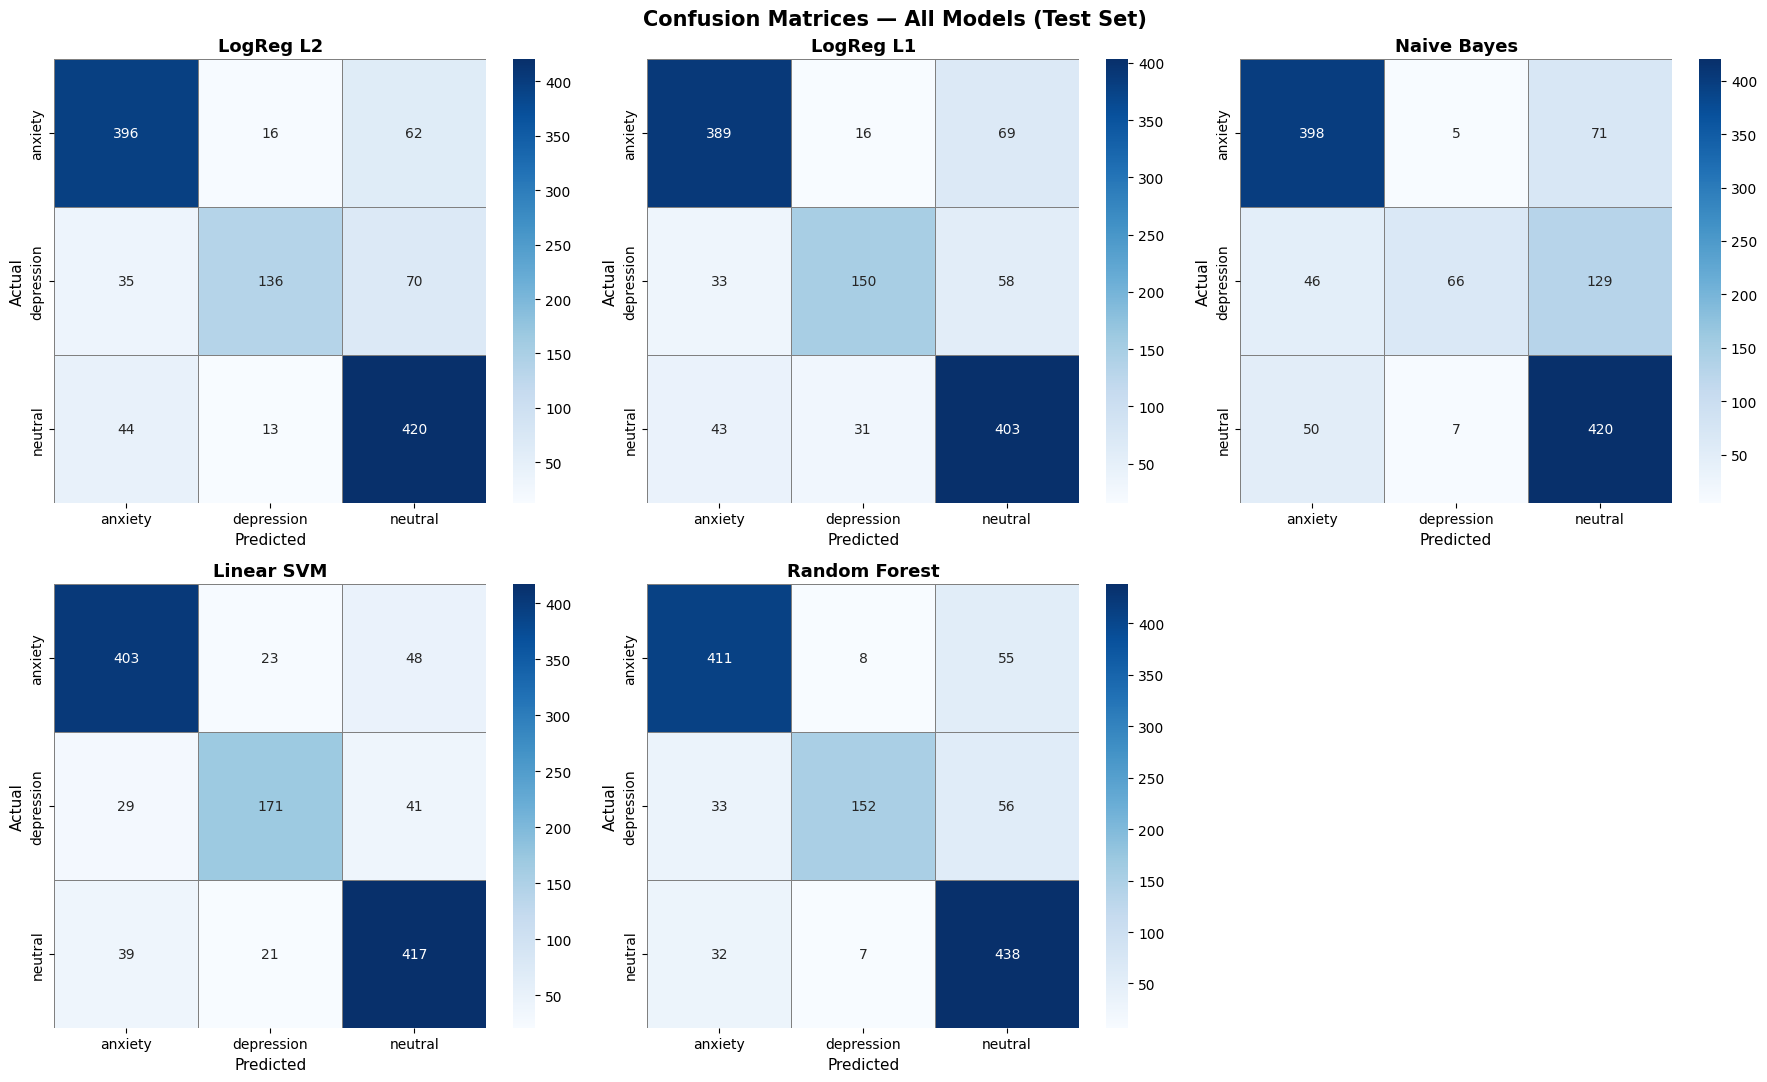

Saved: confusion_matrices.png


In [23]:
# Part 4 - Confusion Matrices
# One heatmap per model, all five shown in a 2x3 grid
# The 6th panel is left blank since we only have 5 models

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    preds = model.predict(X_test)
    cm    = confusion_matrix(y_test, preds, labels=CLASSES)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        cmap="Blues",
        ax=axes_flat[idx],
        linewidths=0.5,
        linecolor="gray"
    )
    axes_flat[idx].set_title(MODEL_LABELS[name], fontsize=13, fontweight="bold")
    axes_flat[idx].set_xlabel("Predicted", fontsize=11)
    axes_flat[idx].set_ylabel("Actual", fontsize=11)

# hide the unused 6th panel
axes_flat[-1].set_visible(False)

plt.suptitle("Confusion Matrices — All Models (Test Set)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()
print("Saved: confusion_matrices.png")

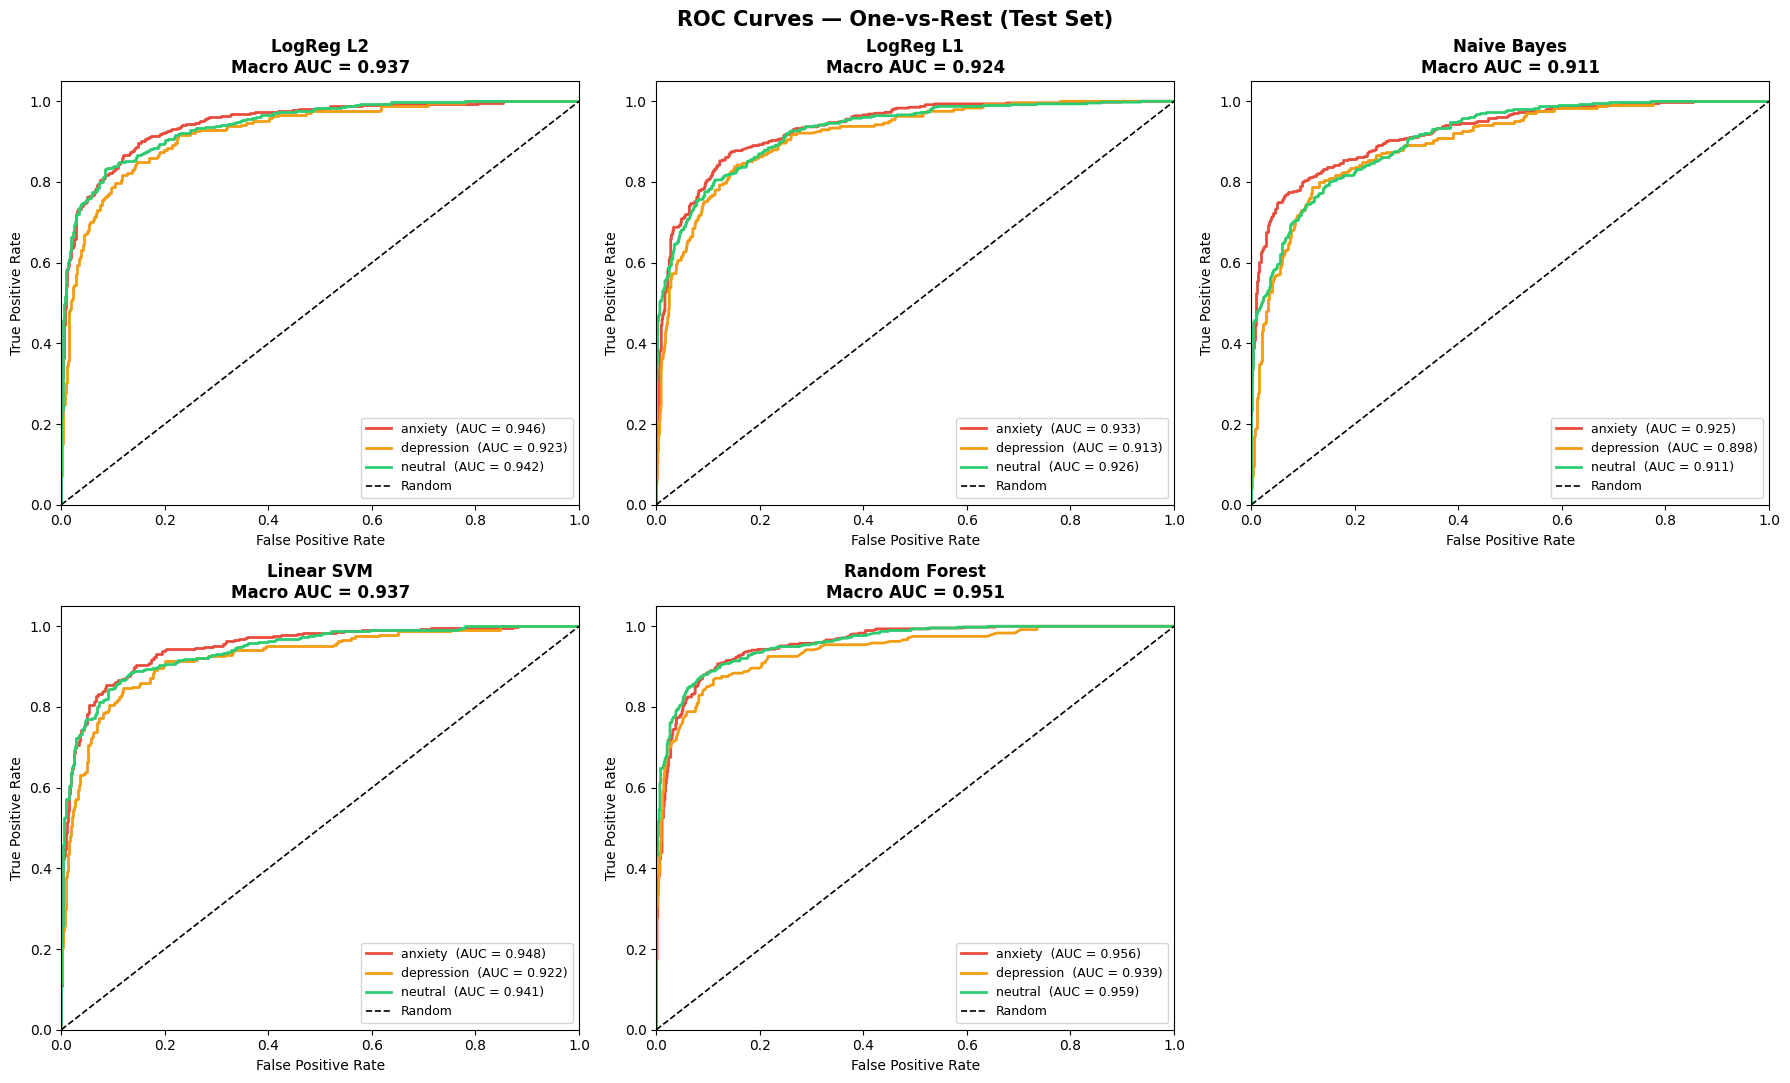

Saved: roc_curves.png


In [24]:
# Part 5 - ROC Curves (One-vs-Rest)
# For LinearSVC we use decision_function since it has no predict_proba
# We normalize those raw scores using MinMaxScaler before computing AUC

y_test_bin = label_binarize(y_test, classes=CLASSES)
colors_roc = ["#e74c3c", "#f39c12", "#2ecc71"]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    ax = axes_flat[idx]

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        raw     = model.decision_function(X_test)
        y_score = MinMaxScaler().fit_transform(raw)

    auc_scores = []

    for i, cls in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_val     = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        auc_scores.append(auc_val)
        ax.plot(fpr, tpr, color=colors_roc[i], lw=2,
                label=f"{cls}  (AUC = {auc_val:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)

    macro_auc = np.mean(auc_scores)
    ax.set_title(f"{MODEL_LABELS[name]}\nMacro AUC = {macro_auc:.3f}",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

axes_flat[-1].set_visible(False)

plt.suptitle("ROC Curves — One-vs-Rest (Test Set)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()
print("Saved: roc_curves.png")

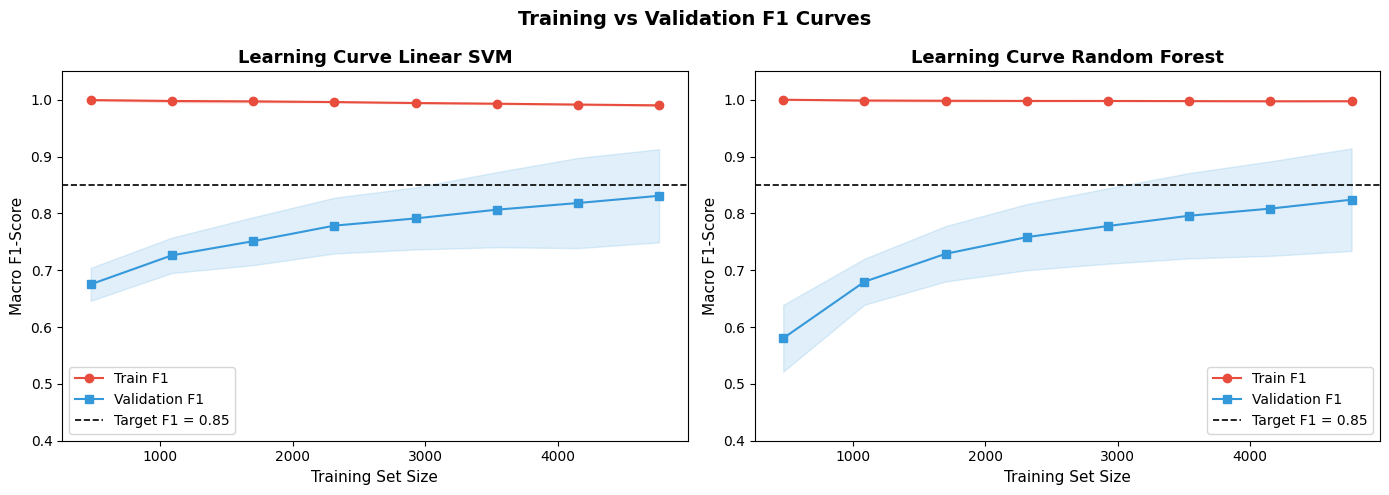

Saved: learning_curves.png


In [25]:
# Part 6 - Learning Curves (Train vs Validation F1)
# Shows whether a model is overfitting or underfitting as data grows
# We pick the top 2 models automatically from eval_df (Part 2)

top2_keys = [k for k, v in MODEL_LABELS.items()
             if v in eval_df["Model"].iloc[:2].values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_sizes_frac = np.linspace(0.1, 1.0, 8)

for ax, name in zip(axes, top2_keys):
    pipe = make_pipeline(name)

    train_sz, tr_scores, val_scores = learning_curve(
        pipe, X_all_text, y_all,
        train_sizes=train_sizes_frac,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1,
        shuffle=True,
        random_state=42,
    )

    tr_mean  = np.mean(tr_scores,  axis=1)
    tr_std   = np.std(tr_scores,   axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std  = np.std(val_scores,  axis=1)

    ax.plot(train_sz, tr_mean,  "o-", color="#e74c3c", label="Train F1")
    ax.fill_between(train_sz, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.15, color="#e74c3c")

    ax.plot(train_sz, val_mean, "s-", color="#3498db", label="Validation F1")
    ax.fill_between(train_sz, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color="#3498db")

    ax.axhline(0.85, color="black", linestyle="--", linewidth=1.2, label="Target F1 = 0.85")
    ax.set_title(f"Learning Curve {MODEL_LABELS[name]}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Set Size", fontsize=11)
    ax.set_ylabel("Macro F1-Score", fontsize=11)
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=10)

plt.suptitle("Training vs Validation F1 Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150)
plt.show()
print("Saved: learning_curves.png")

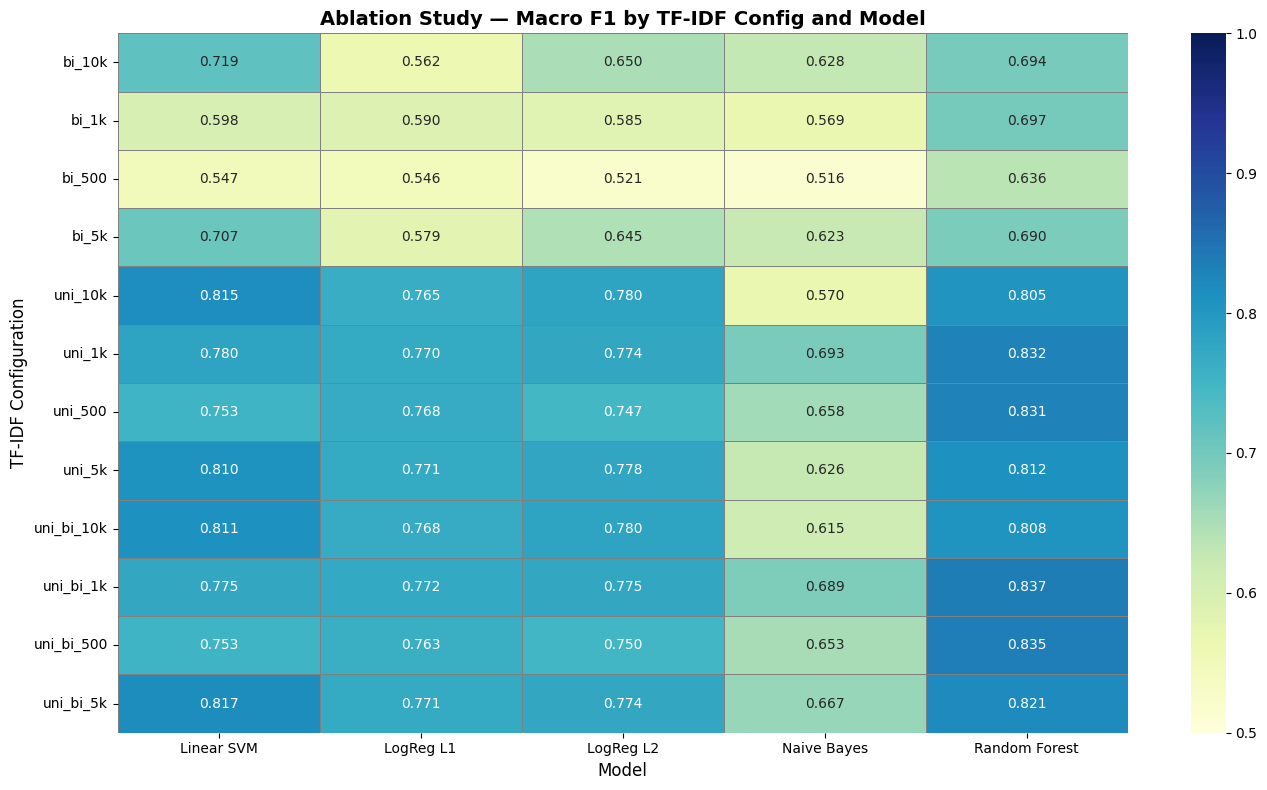

Saved: ablation_heatmap.png


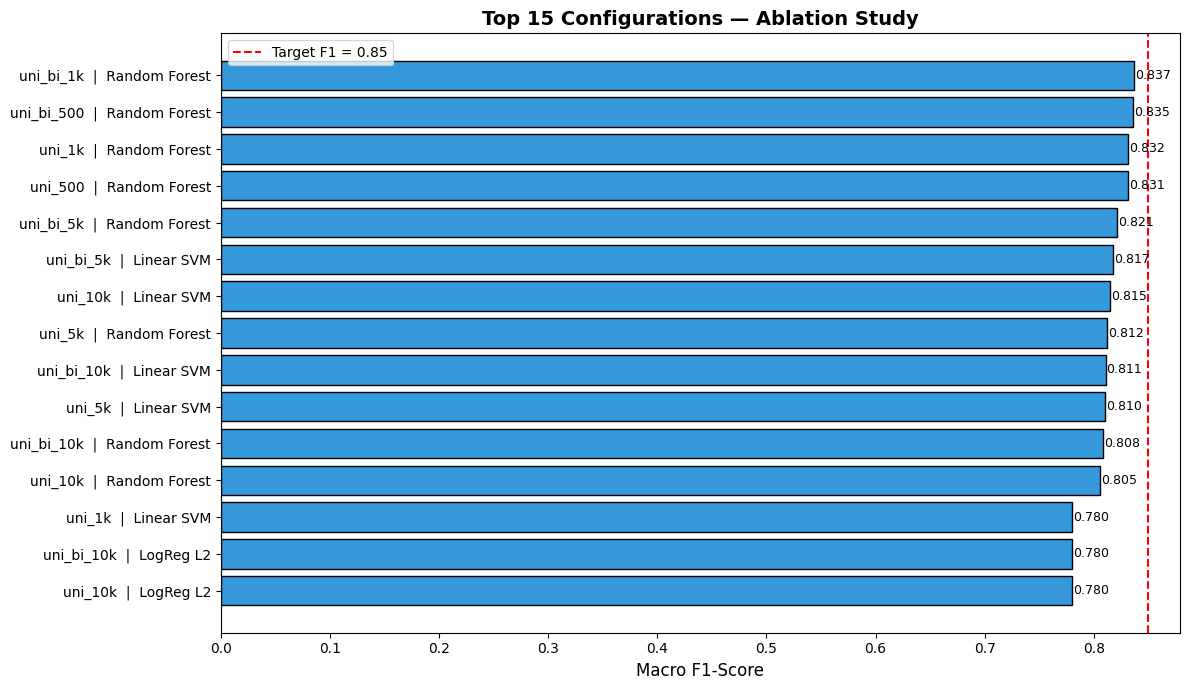

Saved: ablation_top15.png

 Full Ablation Results


,tfidf_name,ngram_range,max_features,model,accuracy,f1_macro
0,uni_bi_1k,"(1, 2)",1000,rf,0.849832,0.837074
1,uni_bi_500,"(1, 2)",500,rf,0.848154,0.835488
2,uni_1k,"(1, 1)",1000,rf,0.845638,0.831679
3,uni_500,"(1, 1)",500,rf,0.847315,0.831020
4,uni_bi_5k,"(1, 2)",5000,rf,0.839765,0.821387
5,uni_bi_5k,"(1, 2)",5000,linear_svm,0.831376,0.817111
6,uni_10k,"(1, 1)",10000,linear_svm,0.831376,0.815106
7,uni_5k,"(1, 1)",5000,rf,0.832215,0.812067
8,uni_bi_10k,"(1, 2)",10000,linear_svm,0.826342,0.810672
9,uni_5k,"(1, 1)",5000,linear_svm,0.827181,0.810279


Saved: ablation_full_results.csv


In [26]:
# Part 7 - Ablation Study
# Uses tfidf_sweep_results from ml's sweep (60 rows = 12 configs x 5 models)
# We make two plots: a heatmap and a ranked top-15 bar chart

ablation = tfidf_sweep_results.copy()
ablation["model_label"] = ablation["model"].map(MODEL_LABELS)

# Heatmap — F1 score for every config and model combination
pivot = ablation.pivot_table(
    index="tfidf_name",
    columns="model_label",
    values="f1_macro",
    aggfunc="mean"
)

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="gray",
    vmin=0.5,
    vmax=1.0
)
plt.title("Ablation Study — Macro F1 by TF-IDF Config and Model",
          fontsize=14, fontweight="bold")
plt.xlabel("Model", fontsize=12)
plt.ylabel("TF-IDF Configuration", fontsize=12)
plt.tight_layout()
plt.savefig("ablation_heatmap.png", dpi=150)
plt.show()
print("Saved: ablation_heatmap.png")

# Top 15 configurations ranked by F1
top15 = tfidf_sweep_results.head(15).copy()
top15["config_label"] = top15["tfidf_name"] + "  |  " + top15["model"].map(MODEL_LABELS)

plt.figure(figsize=(12, 7))
bars = plt.barh(
    top15["config_label"].iloc[::-1].values,
    top15["f1_macro"].iloc[::-1].values,
    color="#3498db",
    edgecolor="black"
)
plt.axvline(0.85, color="red", linestyle="--", linewidth=1.5, label="Target F1 = 0.85")
plt.xlabel("Macro F1-Score", fontsize=12)
plt.title("Top 15 Configurations — Ablation Study", fontsize=14, fontweight="bold")
plt.legend(fontsize=10)

for bar, val in zip(bars, top15["f1_macro"].iloc[::-1].values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("ablation_top15.png", dpi=150)
plt.show()
print("Saved: ablation_top15.png")

# Full results table
print("\n Full Ablation Results")
display(tfidf_sweep_results[["tfidf_name", "ngram_range", "max_features",
                               "model", "accuracy", "f1_macro"]].reset_index(drop=True))

tfidf_sweep_results.to_csv("ablation_full_results.csv", index=False)
print("Saved: ablation_full_results.csv")

Best model         : Random Forest
Total test samples : 1192
Misclassified      : 191  (16.0%)

=== Misclassification Breakdown ===


,true_label,predicted_label,count
3,depression,neutral,56
1,anxiety,neutral,55
2,depression,anxiety,33
4,neutral,anxiety,32
0,anxiety,depression,8
5,neutral,depression,7



=== Sample Misclassified Posts ===

  True Label      : depression
  Predicted Label : neutral
  Text            : cope feeling sad irritable losing numb winning working really hard improve life every aspect past week eat better sleep least hour day begun yoga meditation walking yet still find really enjoy anything always art person like draw finished drawing lon...

  True Label      : depression
  Predicted Label : neutral
  Text            : firing therapist anyone fired long time therapist happy discussion result hard find afraid stop thought...

  True Label      : neutral
  Predicted Label : anxiety
  Text            : suddenly remembering cringe moment anyone suddenly remembering embarrassing cringy thing past feel shitty cringe thing party year ago pop head get...

  True Label      : depression
  Predicted Label : neutral
  Text            : tip keep cry formally diagnosed depression hope mind posting schizotypal british schizophrenia autism diagnosed anything mood much neede

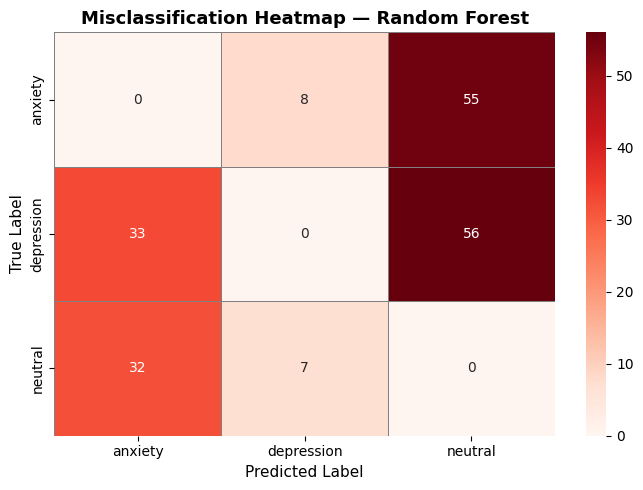

Saved: error_analysis_heatmap.png


In [27]:
# Part 8 - Error Analysis
# take the best model from Part 2 and look at where it went wrong
# Shows a breakdown table, 5 sample mistakes, and a misclassification heatmap

# Pick the best model automatically from eval_df
best_key   = [k for k, v in MODEL_LABELS.items() if v == eval_df.iloc[0]["Model"]][0]
best_model = models[best_key]

# Reset index so predictions line up correctly with the text
X_test_raw   = X_test_text.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
preds_best   = best_model.predict(X_test)

errors_df = pd.DataFrame({
    "preprocessed_text" : X_test_raw,
    "true_label"        : y_test_reset,
    "predicted_label"   : preds_best,
})

errors_df = errors_df[
    errors_df["true_label"] != errors_df["predicted_label"]
].reset_index(drop=True)

n_total = len(y_test)
n_wrong = len(errors_df)

print(f"Best model         : {eval_df.iloc[0]['Model']}")
print(f"Total test samples : {n_total}")
print(f"Misclassified      : {n_wrong}  ({n_wrong / n_total * 100:.1f}%)")

# How many times each true-predicted pair occurred
print("\n=== Misclassification Breakdown ===")
breakdown = (errors_df.groupby(["true_label", "predicted_label"])
                       .size()
                       .reset_index(name="count")
                       .sort_values("count", ascending=False))
display(breakdown)

# A few example posts that the model got wrong
print("\n=== Sample Misclassified Posts ===")
sample_errors = errors_df.sample(min(5, n_wrong), random_state=42)

for _, row in sample_errors.iterrows():
    print(f"\n  True Label      : {row['true_label']}")
    print(f"  Predicted Label : {row['predicted_label']}")
    print(f"  Text            : {row['preprocessed_text'][:250]}...")

errors_df.to_csv("error_analysis.csv", index=False)
print("\nSaved: error_analysis.csv")

# Misclassification heatmap
mis_pivot = (errors_df.groupby(["true_label", "predicted_label"])
                       .size()
                       .unstack(fill_value=0))

plt.figure(figsize=(7, 5))
sns.heatmap(
    mis_pivot,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=0.5,
    linecolor="gray"
)
plt.title(f"Misclassification Heatmap — {eval_df.iloc[0]['Model']}",
          fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.savefig("error_analysis_heatmap.png", dpi=150)
plt.show()
print("Saved: error_analysis_heatmap.png")

In [28]:
display(breakdown)

,true_label,predicted_label,count
3,depression,neutral,56
1,anxiety,neutral,55
2,depression,anxiety,33
4,neutral,anxiety,32
0,anxiety,depression,8
5,neutral,depression,7
